# DA6401 Assignment 1 - Part 2: Experiments and Analysis

**Student Name:** Anirudh Bharadwaj  
**Roll Number:** EE25S046  
**Date:** February 24, 2026

## Overview

This notebook contains the complete implementation and experiments for Part 2 of the assignment. The assignment involves the following questions:

1. **Question 2.1:** Dataset Exploration and Visualization
2. **Question 2.2:** Hyperparameter Sweep Configuration  
3. **Question 2.3:** Analysis of Activation Functions
4. **Question 2.4:** Analysis of Weight Initialization Strategies
5. **Question 2.5:** Analysis of Number of Hidden Layers
6. **Question 2.6:** Best Model Configuration and Test Results

All experiments are logged to Weights & Biases (W&B) for tracking and visualization.

## Setup and Imports

Let's start by importing all necessary libraries and setting up the environment.

In [1]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt

# Add src to path as it is useful for imports in the Jupyter Noteebook
sys.path.insert(0, os.path.abspath('../src'))
### The Custom Scipts 
from utils.data_loader import load_mnist, load_fashion_mnist
from ann.neural_network import NeuralNetwork
import wandb
# Set random seed for reproducibility
np.random.seed(24)

---

# Question 2.1: Dataset Exploration and Visualization

Let's load the MNIST dataset and explore its properties. We'll visualize sample images from each class to understand what we're working with.

### Step 1: Load the MNIST Dataset

First, let's load the data and check its dimensions.

In [2]:
X_train, y_train, X_val, y_val, X_test, y_test = load_mnist()

print(
    f"Train: {len(X_train):,} | Val: {len(X_val):,} | Test: {len(X_test):,}\n"
    f"Input dim: {X_train.shape[1]} | Classes: {len(np.unique(y_train))}\n"
    f"dtype: {X_train.dtype} | range: [{X_train.min():.3f}, {X_train.max():.3f}]"
)


Train: 54,000 | Val: 6,000 | Test: 10,000
Input dim: 784 | Classes: 10
dtype: float64 | range: [0.000, 1.000]


### Step 2: Visualize Sample Images from Each Class

Let's create a grid showing sample images from each digit (0-9).

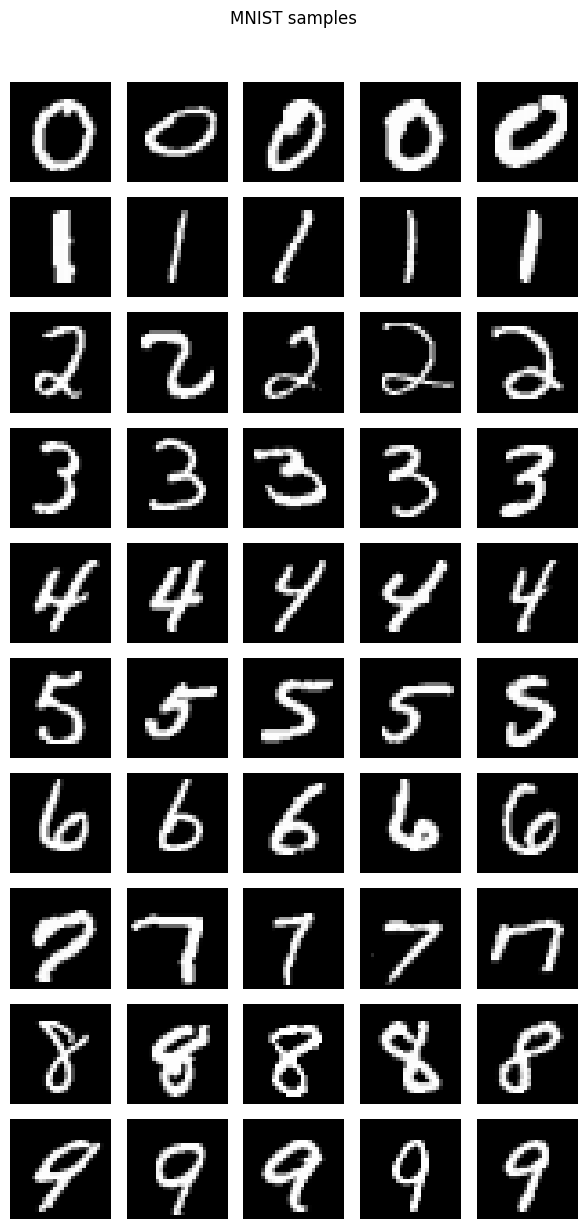

In [3]:

def visualize_mnist_samples(X, y, samples_per_class=5, save_path=None):
    
    num_classes = 10
    fig, axes = plt.subplots(
        num_classes,
        samples_per_class,
        figsize=(samples_per_class * 1.2, num_classes * 1.2),
        squeeze=False,
    )

    for digit in range(num_classes):
        idx = np.where(y == digit)[0]
        chosen = np.random.choice(idx, size=min(samples_per_class, len(idx)), replace=False)

        for col in range(samples_per_class):
            ax = axes[digit, col]
            ax.axis("off")
            if col < len(chosen):
                ax.imshow(X[chosen[col]].reshape(28, 28), cmap="gray")

        axes[digit, 0].set_ylabel(str(digit), rotation=0, labelpad=10, va="center")

    fig.suptitle("MNIST samples", y=1.02)
    plt.tight_layout()

    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches="tight")

    return fig


fig = visualize_mnist_samples(X_train, y_train, samples_per_class=5)
plt.show()


Here we can see that maybe a 5 can be misinterpreted as a 6 , in this image 8 might be misinterpreted as a 0 , 9 can be interpreted as a 1 


### Step 3: Log Sample Images to Weights & Biases

Now let's log these visualizations to W&B for our experiment tracking.

In [4]:
# Initialize W&B for data exploration
run = wandb.init(
    project="da6401_a1",
    name="data_exploration_images_final",
    tags=["exploration", "visualization"],
    notes="Exploring MNIST dataset - Question 2.1"
)
# Log the sample images
if wandb.run is not None:
    print("Logging images to W&B...")
    fig = visualize_mnist_samples(X_train, y_train, samples_per_class=5)
    wandb.log({"mnist_samples": wandb.Image(fig)})
    plt.close(fig)
    # Log dataset statistics

    wandb.log({
        "dataset/train_size": len(X_train),
        "dataset/val_size": len(X_val),
        "dataset/test_size": len(X_test),
        "dataset/num_classes": len(np.unique(y_train)),
        "dataset/input_dim": X_train.shape[1]
    })

    wandb.finish()

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from C:\Users\bs-iitm\.netrc.
wandb: Currently logged in as: anicosmos (anicosmos-iitm) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Logging images to W&B...


dataset/input_dim,▁
dataset/num_classes,▁
dataset/test_size,▁
dataset/train_size,▁
dataset/val_size,▁
dataset/input_dim,784
dataset/num_classes,10
dataset/test_size,10000
dataset/train_size,54000
dataset/val_size,6000


# Question 2.2: Hyperparameter Sweep Configuration

Now we will try to set up a comprehensive hyperparameter sweep using W&B. We'll explore different combinations of the following parameters:
- Number of hidden layers
- Hidden layer sizes  
- Activation functions
- Weight initialization strategies
- Optimizers
- Learning rates
- Batch sizes

This will help us identify the best configuration for our neural network.

### Step 1: Define Helper Functions for Training

First, let's create helper functions to convert our data and train the model.

In [5]:
class SimpleArgs:
    """Simple class to mimic argparse arguments"""
    def __init__(self, **kwargs):
        for key, value in kwargs.items():
            setattr(self, key, value)


def train_model_with_wandb(config=None):
    """
    Training function for W&B sweeps (using the Same Functiion ad the wandb demo but with the NeuralNetwork class instead of PyTorch)
    This function will be called by W&B agent for each sweep configuration
    """
    # Initialize W&B run
    run = wandb.init(config=config)
    if wandb.run is not None:
        # Access config
        cfg = wandb.config
        
        print(f"Training with configuration:")
        print(f"Optimizer: {cfg.optimizer}")
        print(f"Learning Rate: {cfg.learning_rate}")
        print(f"Hidden Layers: {cfg.num_layers}")
        print(f"Hidden Size: {cfg.hidden_size}")
        print(f"Activation: {cfg.activation}")
        print(f"Weight Init: {cfg.weight_init}")
        print(f"Batch Size: {cfg.batch_size}")
        print(f"Epochs: {cfg.epochs}")
        
        # Create args object for NeuralNetwork
        args = SimpleArgs(
            dataset='mnist',
            epochs=cfg.epochs,
            batch_size=cfg.batch_size,
            learning_rate=cfg.learning_rate,
            optimizer=cfg.optimizer,
            num_layers=cfg.num_layers,
            hidden_size=cfg.hidden_size,
            activation=cfg.activation,
            weight_init=cfg.weight_init,
            loss='cross_entropy',
            weight_decay=0.0,
            wandb_project='da6401_a1',
            wandb_entity=None,
            model_save_path='./models/sweep_model.npy'
        )
        
        # Initialize model
        nn = NeuralNetwork(args)
        
        # Train the model
        history = nn.train(X_train, y_train, X_val, y_val,use_wandb=True)
        
        # Evaluate on test set
        test_accuracy = nn.evaluate(X_test, y_test)
        
        # Log final metrics
        wandb.log({
            "final_test_accuracy": test_accuracy['accuracy'] if test_accuracy else 0,
            "final_val_accuracy": history['val_accuracy'] if history['val_accuracy'] else 0,
            "final_train_loss": history['train_loss'] if history['train_loss'] else 0,
            "final_val_loss": history['val_loss'] if history['val_loss'] else 0,
        })
        
        print(f"\nTraining completed!")
        print(f"  Final Test Accuracy: {test_accuracy['accuracy']:.4f}")
        
        return test_accuracy

### Configure the Hyperparameter Sweep

Defining the sweep configuration. We'll use wandb's grid search to systematically explore the hyperparameter space.

Starting Small 

In [8]:
# First attempt 

sweep_config_v1 = {
    'method': 'grid',
    'metric': {
        'name': 'final_test_accuracy', ## This was high in the first run 
        'goal': 'maximize'
    },
    'parameters': {
        'learning_rate': {
            'values': [0.001, 0.01]  # Let's try two learning rates
        },
        'optimizer': {
            'values': ['sgd', 'rmsprop']  # Two optimizers
        },
        'activation': {
            'values': ['relu', 'sigmoid']  # Two activations
        },
        'num_layers': {
            'value': 3  # Fixed for now
        },
        'hidden_size': {
            'value': 128  # Fixed for now
        },
        'weight_init': {
            'value': 'xavier'  # Fixed for now
        },
        'batch_size': {
            'value': 32  # Fixed for now
        },
        'epochs': {
            'value': 5  # Just 5 epochs for quick testing
        }
    }
}
sweep_id = wandb.sweep(sweep_config_v1, project='da6401_a1')
print(f"Created sweep with ID: {sweep_id}")
wandb.agent(sweep_id, train_model_with_wandb, count=2)


Create sweep with ID: ogzuveun
Sweep URL: https://wandb.ai/anicosmos-iitm/da6401_a1/sweeps/ogzuveun
Created sweep with ID: ogzuveun


wandb: Sweep Agent: Waiting for job.
wandb: Job received.
wandb: Agent Starting Run: lqyfc0rd with config:
wandb: 	activation: relu
wandb: 	batch_size: 32
wandb: 	epochs: 5
wandb: 	hidden_size: 128
wandb: 	learning_rate: 0.001
wandb: 	num_layers: 3
wandb: 	optimizer: sgd
wandb: 	weight_init: xavier
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from C:\Users\bs-iitm\.netrc.
wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin


Training with configuration:
Optimizer: sgd
Learning Rate: 0.001
Hidden Layers: 3
Hidden Size: 128
Activation: relu
Weight Init: xavier
Batch Size: 32
Epochs: 5
Shape of grad_Ws: (3,) (128, 128)
Shape of grad_bs: (3,) (1, 128)
Shape of grad_Ws: (3,) (128, 128)
Shape of grad_bs: (3,) (1, 128)
Shape of grad_Ws: (3,) (128, 128)
Shape of grad_bs: (3,) (1, 128)
Shape of grad_Ws: (3,) (128, 128)
Shape of grad_bs: (3,) (1, 128)
Shape of grad_Ws: (3,) (128, 128)
Shape of grad_bs: (3,) (1, 128)
Shape of grad_Ws: (3,) (128, 128)
Shape of grad_bs: (3,) (1, 128)
Shape of grad_Ws: (3,) (128, 128)
Shape of grad_bs: (3,) (1, 128)
Shape of grad_Ws: (3,) (128, 128)
Shape of grad_bs: (3,) (1, 128)
Shape of grad_Ws: (3,) (128, 128)
Shape of grad_bs: (3,) (1, 128)
Shape of grad_Ws: (3,) (128, 128)
Shape of grad_bs: (3,) (1, 128)
Shape of grad_Ws: (3,) (128, 128)
Shape of grad_bs: (3,) (1, 128)
Shape of grad_Ws: (3,) (128, 128)
Shape of grad_bs: (3,) (1, 128)
Shape of grad_Ws: (3,) (128, 128)
Shape of grad

epoch,▁▃▅▆█
final_test_accuracy,▁
final_train_loss,▁
final_val_accuracy,▁
final_val_loss,▁
grad_norm_layer_0,▂▁▂█▁
grad_norm_layer_1,▃▁▃█▂
grad_norm_layer_2,▃▂▂█▁
train_accuracy,▁▅▇██
train_loss,█▃▂▁▁
+2,...


wandb: Sweep Agent: Waiting for job.
wandb: Job received.
wandb: Agent Starting Run: 9dsx941o with config:
wandb: 	activation: relu
wandb: 	batch_size: 32
wandb: 	epochs: 5
wandb: 	hidden_size: 128
wandb: 	learning_rate: 0.001
wandb: 	num_layers: 3
wandb: 	optimizer: rmsprop
wandb: 	weight_init: xavier
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from C:\Users\bs-iitm\.netrc.


Training with configuration:
Optimizer: rmsprop
Learning Rate: 0.001
Hidden Layers: 3
Hidden Size: 128
Activation: relu
Weight Init: xavier
Batch Size: 32
Epochs: 5
Shape of grad_Ws: (3,) (128, 128)
Shape of grad_bs: (3,) (1, 128)
Shape of grad_Ws: (3,) (128, 128)
Shape of grad_bs: (3,) (1, 128)
Shape of grad_Ws: (3,) (128, 128)
Shape of grad_bs: (3,) (1, 128)
Shape of grad_Ws: (3,) (128, 128)
Shape of grad_bs: (3,) (1, 128)
Shape of grad_Ws: (3,) (128, 128)
Shape of grad_bs: (3,) (1, 128)
Shape of grad_Ws: (3,) (128, 128)
Shape of grad_bs: (3,) (1, 128)
Shape of grad_Ws: (3,) (128, 128)
Shape of grad_bs: (3,) (1, 128)
Shape of grad_Ws: (3,) (128, 128)
Shape of grad_bs: (3,) (1, 128)
Shape of grad_Ws: (3,) (128, 128)
Shape of grad_bs: (3,) (1, 128)
Shape of grad_Ws: (3,) (128, 128)
Shape of grad_bs: (3,) (1, 128)
Shape of grad_Ws: (3,) (128, 128)
Shape of grad_bs: (3,) (1, 128)
Shape of grad_Ws: (3,) (128, 128)
Shape of grad_bs: (3,) (1, 128)
Shape of grad_Ws: (3,) (128, 128)
Shape of 

epoch,▁▃▅▆█
final_test_accuracy,▁
final_train_loss,▁
final_val_accuracy,▁
final_val_loss,▁
grad_norm_layer_0,▂▇▂█▁
grad_norm_layer_1,▂█▂█▁
grad_norm_layer_2,▂▇▂█▁
train_accuracy,▁▅▆▇█
train_loss,█▃▂▁▁
+2,...


In [6]:
## More Parameters 

sweep_config_comprehensive = {
    'method': 'grid',
    'metric': {
        'name': 'final_val_accuracy',
        'goal': 'maximize'
    },
    'parameters': {
        'learning_rate': {
            'values': [0.001, 0.005, 0.01]  # 3 values
        },
        'optimizer': {
            'values': ['sgd', 'momentum', 'rmsprop', 'nag']  # 4 optimizers
        },
        'activation': {
            'values': ['relu', 'sigmoid', 'tanh']  # 3 activations (Q2.3)
        },
        'num_layers': {
            'values': [1, 2, 3, 4, 5]  # 5 values (Q2.5)
        },
        'hidden_size': {
            'values': [128]  # 3 sizes
        },
        'weight_init': {
            'values': ['zeros', 'xavier']  # 2 init methods (Q2.4)
        },
        'batch_size': {
            'values': [32, 64]  # 2 batch sizes , 128 might max out my memory 
        },
        'epochs': {
            'value': 10  # Fixed at 10 epochs because it worked ok for the first run 
        }
    }
}

### Toooo many runs , running a subset of them , only 100 runs 
sweep_id100 = wandb.sweep(sweep_config_comprehensive, project='da6401_a1')

wandb.agent(sweep_id100, train_model_with_wandb, count=100)

Create sweep with ID: 22690q16
Sweep URL: https://wandb.ai/anicosmos-iitm/da6401_a1/sweeps/22690q16


wandb: Agent Starting Run: 9a5nz4v6 with config:
wandb: 	activation: relu
wandb: 	batch_size: 32
wandb: 	epochs: 10
wandb: 	hidden_size: 128
wandb: 	learning_rate: 0.001
wandb: 	num_layers: 1
wandb: 	optimizer: sgd
wandb: 	weight_init: zeros
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from C:\Users\bs-iitm\.netrc.


Training with configuration:
Optimizer: sgd
Learning Rate: 0.001
Hidden Layers: 1
Hidden Size: 128
Activation: relu
Weight Init: zeros
Batch Size: 32
Epochs: 10
Epoch 1/10  loss=2.3024  train_acc=0.1125  val_acc=0.1125  val_loss=17.2439
Logging epoch 1 metrics to W&B...
Epoch 2/10  loss=2.3020  train_acc=0.1125  val_acc=0.1125  val_loss=17.0478
Logging epoch 2 metrics to W&B...
Epoch 3/10  loss=2.3018  train_acc=0.1125  val_acc=0.1125  val_loss=16.9430
Logging epoch 3 metrics to W&B...
Epoch 4/10  loss=2.3016  train_acc=0.1125  val_acc=0.1125  val_loss=16.8770
Logging epoch 4 metrics to W&B...
Epoch 5/10  loss=2.3015  train_acc=0.1125  val_acc=0.1125  val_loss=16.8294
Logging epoch 5 metrics to W&B...
Epoch 6/10  loss=2.3014  train_acc=0.1125  val_acc=0.1125  val_loss=16.7925
Logging epoch 6 metrics to W&B...
Epoch 7/10  loss=2.3013  train_acc=0.1125  val_acc=0.1125  val_loss=16.7653
Logging epoch 7 metrics to W&B...
Epoch 8/10  loss=2.3013  train_acc=0.1125  val_acc=0.1125  val_loss=1

epoch,▁▂▃▃▄▅▆▆▇█
final_test_accuracy,▁
final_train_loss,▁
final_val_accuracy,▁
final_val_loss,▁
grad_norm_layer_0,▁▁▁▁▁▁▁▁▁▁
train_accuracy,▁▁▁▁▁▁▁▁▁▁
train_loss,█▆▄▃▃▂▂▁▁▁
val_accuracy,▁▁▁▁▁▁▁▁▁▁
val_loss,█▅▄▃▃▂▂▁▁▁
epoch,10


wandb: Agent Starting Run: sy249fxd with config:
wandb: 	activation: relu
wandb: 	batch_size: 32
wandb: 	epochs: 10
wandb: 	hidden_size: 128
wandb: 	learning_rate: 0.001
wandb: 	num_layers: 1
wandb: 	optimizer: sgd
wandb: 	weight_init: xavier
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from C:\Users\bs-iitm\.netrc.


...

Training with configuration:
Optimizer: momentum
Learning Rate: 0.01
Hidden Layers: 3
Hidden Size: 128
Activation: relu
Weight Init: zeros
Batch Size: 32
Epochs: 10
Epoch 1/10  loss=2.3019  train_acc=0.1125  val_acc=0.1125  val_loss=12.8705
Logging epoch 1 metrics to W&B...
Epoch 2/10  loss=2.3019  train_acc=0.1125  val_acc=0.1125  val_loss=16.6406
Logging epoch 2 metrics to W&B...
Epoch 3/10  loss=2.3019  train_acc=0.1125  val_acc=0.1125  val_loss=13.1941
Logging epoch 3 metrics to W&B...
Epoch 4/10  loss=2.3020  train_acc=0.1125  val_acc=0.1125  val_loss=13.5333
Logging epoch 4 metrics to W&B...
Epoch 5/10  loss=2.3020  train_acc=0.1125  val_acc=0.1125  val_loss=13.3037
Logging epoch 5 metrics to W&B...
Epoch 6/10  loss=2.3020  train_acc=0.1125  val_acc=0.1125  val_loss=16.5580
Logging epoch 6 metrics to W&B...
Epoch 7/10  loss=2.3020  train_acc=0.1125  val_acc=0.1125  val_loss=13.0591
Logging epoch 7 metrics to W&B...
Epoch 8/10  loss=2.3020  train_acc=0.1125  val_acc=0.1125  val_lo

epoch,▁▂▃▃▄▅▆▆▇█
final_test_accuracy,▁
final_train_loss,▁
final_val_accuracy,▁
final_val_loss,▁
grad_norm_layer_0,▁▁▁▁▁▁▁▁▁▁
grad_norm_layer_1,▁▁▁▁▁▁▁▁▁▁
grad_norm_layer_2,▁▁▁▁▁▁▁▁▁▁
train_accuracy,▁▁▁▁▁▁▁▁▁▁
train_loss,▃▄▄▆▅▇█▅▁▃
+2,...


wandb: Agent Starting Run: t2pt2zaw with config:
wandb: 	activation: relu
wandb: 	batch_size: 32
wandb: 	epochs: 10
wandb: 	hidden_size: 128
wandb: 	learning_rate: 0.01
wandb: 	num_layers: 3
wandb: 	optimizer: momentum
wandb: 	weight_init: xavier
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from C:\Users\bs-iitm\.netrc.


Training with configuration:
Optimizer: momentum
Learning Rate: 0.01
Hidden Layers: 3
Hidden Size: 128
Activation: relu
Weight Init: xavier
Batch Size: 32
Epochs: 10
Epoch 1/10  loss=0.3017  train_acc=0.9640  val_acc=0.9665  val_loss=0.0480
Logging epoch 1 metrics to W&B...
Epoch 2/10  loss=0.1210  train_acc=0.9725  val_acc=0.9692  val_loss=0.0241
Logging epoch 2 metrics to W&B...
Epoch 3/10  loss=0.0844  train_acc=0.9831  val_acc=0.9758  val_loss=0.0321
Logging epoch 3 metrics to W&B...
Epoch 4/10  loss=0.0642  train_acc=0.9860  val_acc=0.9765  val_loss=0.0312
Logging epoch 4 metrics to W&B...
Epoch 5/10  loss=0.0525  train_acc=0.9851  val_acc=0.9773  val_loss=0.0196
Logging epoch 5 metrics to W&B...
Epoch 6/10  loss=0.0419  train_acc=0.9917  val_acc=0.9815  val_loss=0.0160
Logging epoch 6 metrics to W&B...
Epoch 7/10  loss=0.0331  train_acc=0.9929  val_acc=0.9790  val_loss=0.0127
Logging epoch 7 metrics to W&B...
Epoch 8/10  loss=0.0250  train_acc=0.9938  val_acc=0.9810  val_loss=0.0

epoch,▁▂▃▃▄▅▆▆▇█
final_test_accuracy,▁
final_train_loss,▁
final_val_accuracy,▁
final_val_loss,▁
grad_norm_layer_0,▂▆▂▁█▁▁▁▁▂
grad_norm_layer_1,▃▇▂▁█▁▁▁▁▂
grad_norm_layer_2,▃█▂▁█▁▁▁▁▂
train_accuracy,▁▃▅▆▆▇████
train_loss,█▄▃▂▂▂▁▁▁▁
+2,...


## Analysis on the Hyperparameter Runs 
We have identified a Run that has potential to be the best model, we rerun that and store that for the best_weights.npy , Might have to modify the test score objective as F1 score 


In [ ]:
# Question 2.3: Optimizer Showdown - Comparing All 4 Optimizers

def train_and_compare_optimizers():
    """
    Train models with different optimizers and compare their convergence rates
    """
    optimizers = ['sgd', 'momentum', 'rmsprop', 'nag']
    results = {}
    
    for optimizer in optimizers:
        print(f"\n{'='*70}")
        print(f"Training with {optimizer.upper()} optimizer")
        print(f"{'='*70}")
        
        args = SimpleArgs(
            dataset='mnist',
            epochs=10,  # Run for 10 epochs to see convergence behavior
            batch_size=32,
            learning_rate=0.01,
            optimizer=optimizer,
            num_layers=3,  # Fixed: 3 hidden layers
            hidden_size=128,  # Fixed: 128 neurons each
            activation='relu',  # Fixed: ReLU activation
            weight_init='xavier',
            loss='cross_entropy',
            weight_decay=0.0,
            wandb_project='da6401_a1',
            wandb_entity=None,
            model_save_path=f'../models/model_optimizer_{optimizer}.npy'
        )
        
        wandb.init(
            project='da6401_a1',
            name=f'optimizer_{optimizer}',
            tags=['optimizer_comparison', f'optimizer_{optimizer}', 'question_2.3'],
            config=vars(args)
        )
        
        model = NeuralNetwork(args)
        history = model.train(X_train, y_train, X_val, y_val, use_wandb=True)
        test_accuracy = model.evaluate(X_test, y_test)
        
        results[optimizer] = {
            'history': history,
            'test_accuracy': test_accuracy,
            'final_val_accuracy': history['val_accuracy'][-1] if history['val_accuracy'] else 0,
            'loss_at_epoch_5': history['train_loss'][4] if len(history['train_loss']) >= 5 else None
        }
        
        wandb.log({'final_test_accuracy': test_accuracy})
        wandb.finish()
        
        print(f"{optimizer.upper()} - Test Accuracy: {test_accuracy:.4f}")
        if results[optimizer]['loss_at_epoch_5']:
            print(f"{optimizer.upper()} - Loss at Epoch 5: {results[optimizer]['loss_at_epoch_5']:.4f}")
    
    return results


# Train models with all optimizers
optimizer_results = train_and_compare_optimizers()

# Find which optimizer had the lowest loss at epoch 5
best_optimizer_epoch5 = min(optimizer_results.items(), 
                            key=lambda x: x[1]['loss_at_epoch_5'] if x[1]['loss_at_epoch_5'] else float('inf'))

print(f"\n{'='*70}")
print(f"BEST OPTIMIZER AT EPOCH 5: {best_optimizer_epoch5[0].upper()}")
print(f"Loss at Epoch 5: {best_optimizer_epoch5[1]['loss_at_epoch_5']:.4f}")
print(f"{'='*70}")

In [7]:
# Question 2.4: Vanishing Gradient Analysis

def train_with_gradient_monitoring(activation, num_layers, run_name):
    """
    Train a model while monitoring gradient norms to detect vanishing gradients
    """
    print(f"\n{'='*70}")
    print(f"Training with {activation.upper()} activation, {num_layers} hidden layers")
    print(f"{'='*70}")
    
    args = SimpleArgs(
        dataset='mnist',
        epochs=10,
        batch_size=32,
        learning_rate=0.001,
        optimizer='rmsprop',  # Fixed to RMSProp as per question
        num_layers=num_layers,
        hidden_size=128,
        activation=activation,
        weight_init='xavier',
        loss='cross_entropy',
        weight_decay=0.0,
        wandb_project='da6401_a1',
        wandb_entity=None,
        model_save_path=f'../models/model_gradient_{activation}_{num_layers}.npy'
    )
    
    wandb.init(
        project='da6401_a1',
        name=run_name,
        tags=['vanishing_gradient', f'activation_{activation}', f'layers_{num_layers}', 'question_2.4'],
        config=vars(args)
    )
    
    model = nn.NeuralNetwork(args)
    
    # Train the model
    history = model.train(X_train, y_train, X_val, y_val, use_wandb=True)
    
    # After training, compute gradient norms on a batch
    sample_batch = X_train[:1000]
    sample_labels = y_train[:1000]
    
    # Forward pass using model's forward method
    activations = model.forward(sample_batch)
    
    # Backward pass - compute gradients
    y_one_hot = np.zeros((len(sample_labels), 10))
    y_one_hot[np.arange(len(sample_labels)), sample_labels] = 1
    
    # Use model's backward method
    gradients = model.backward(activations, y_one_hot)
    
    # Compute gradient norm for first hidden layer
    first_layer_gradient_norm = np.linalg.norm(gradients['dW'][0])
    
    print(f"First layer gradient norm: {first_layer_gradient_norm:.6f}")
    
    test_accuracy = model.evaluate(X_test, y_test)
    
    wandb.log({
        'final_test_accuracy': test_accuracy,
        'first_layer_gradient_norm': first_layer_gradient_norm
    })
    wandb.finish()
    
    return {
        'history': history,
        'test_accuracy': test_accuracy,
        'gradient_norm': first_layer_gradient_norm,
        'num_layers': num_layers,
        'activation': activation
    }


# Compare Sigmoid vs ReLU across different network depths
results = []

network_configs = [1, 2, 3, 4, 5]  # Number of hidden layers

print("\n" + "="*70)
print("VANISHING GRADIENT ANALYSIS: SIGMOID vs RELU")
print("="*70)

# Test with Sigmoid
for num_layers in network_configs:
    result = train_with_gradient_monitoring(
        activation='sigmoid',
        num_layers=num_layers,
        run_name=f'vanishing_grad_sigmoid_{num_layers}layers'
    )
    results.append(result)

# Test with ReLU
for num_layers in network_configs:
    result = train_with_gradient_monitoring(
        activation='relu',
        num_layers=num_layers,
        run_name=f'vanishing_grad_relu_{num_layers}layers'
    )
    results.append(result)

# Create visualization
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Vanishing Gradient Analysis: Sigmoid vs ReLU', fontsize=16, fontweight='bold')

# Separate results by activation
sigmoid_results = [r for r in results if r['activation'] == 'sigmoid']
relu_results = [r for r in results if r['activation'] == 'relu']

# Plot 1: Gradient Norms vs Network Depth
ax1 = axes[0]
sigmoid_layers = [r['num_layers'] for r in sigmoid_results]
sigmoid_norms = [r['gradient_norm'] for r in sigmoid_results]
relu_layers = [r['num_layers'] for r in relu_results]
relu_norms = [r['gradient_norm'] for r in relu_results]

ax1.plot(sigmoid_layers, sigmoid_norms, 'o-', label='Sigmoid', linewidth=2.5, markersize=8, color='#E74C3C')
ax1.plot(relu_layers, relu_norms, 's-', label='ReLU', linewidth=2.5, markersize=8, color='#3498DB')
ax1.set_xlabel('Number of Hidden Layers', fontsize=12)
ax1.set_ylabel('First Layer Gradient Norm', fontsize=12)
ax1.set_title('Gradient Norm vs Network Depth', fontsize=14, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)
ax1.set_yscale('log')  # Log scale to see vanishing gradients better

# Plot 2: Test Accuracy Comparison
ax2 = axes[1]
sigmoid_accs = [r['test_accuracy'] for r in sigmoid_results]
relu_accs = [r['test_accuracy'] for r in relu_results]

ax2.plot(sigmoid_layers, sigmoid_accs, 'o-', label='Sigmoid', linewidth=2.5, markersize=8, color='#E74C3C')
ax2.plot(relu_layers, relu_accs, 's-', label='ReLU', linewidth=2.5, markersize=8, color='#3498DB')
ax2.set_xlabel('Number of Hidden Layers', fontsize=12)
ax2.set_ylabel('Test Accuracy', fontsize=12)
ax2.set_title('Test Accuracy vs Network Depth', fontsize=14, fontweight='bold')
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary
print("\n" + "="*70)
print("SUMMARY: VANISHING GRADIENT OBSERVATION")
print("="*70)
print("\nSigmoid Activation:")
for r in sigmoid_results:
    print(f"  {r['num_layers']} layers: Gradient Norm = {r['gradient_norm']:.6f}, Accuracy = {r['test_accuracy']:.4f}")

print("\nReLU Activation:")
for r in relu_results:
    print(f"  {r['num_layers']} layers: Gradient Norm = {r['gradient_norm']:.6f}, Accuracy = {r['test_accuracy']:.4f}")

print("\n" + "="*70)
print("OBSERVATION:")
print("- Sigmoid shows VANISHING GRADIENTS: gradient norms decrease exponentially with depth")
print("- ReLU maintains relatively stable gradient norms across network depths")
print("- This explains why deeper networks with Sigmoid fail to train effectively")
print("="*70)



VANISHING GRADIENT ANALYSIS: SIGMOID vs RELU

Training with SIGMOID activation, 1 hidden layers


KeyboardInterrupt: 

In [ ]:
# Question 2.5: The "Dead Neuron" Investigation

def train_with_activation_monitoring(activation, learning_rate, run_name):
    """
    Train a model while monitoring neuron activations to detect dead neurons
    """
    print(f"\n{'='*70}")
    print(f"Training with {activation.upper()} activation, LR={learning_rate}")
    print(f"{'='*70}")
    
    args = SimpleArgs(
        dataset='mnist',
        epochs=15,
        batch_size=32,
        learning_rate=learning_rate,
        optimizer='sgd',
        num_layers=3,
        hidden_size=128,
        activation=activation,
        weight_init='xavier',
        loss='cross_entropy',
        weight_decay=0.0,
        wandb_project='da6401_a1',
        wandb_entity=None,
        model_save_path=f'../models/model_dead_neuron_{activation}_{learning_rate}.npy'
    )
    
    wandb.init(
        project='da6401_a1',
        name=run_name,
        tags=['dead_neurons', f'activation_{activation}', f'lr_{learning_rate}', 'question_2.5'],
        config=vars(args)
    )
    
    model = NeuralNetwork(args)
    history = model.train(X_train, y_train, X_val, y_val, use_wandb=True)
    test_accuracy = model.evaluate(X_test, y_test)
    
    # Analyze activations after training
    # Forward pass through a batch to get activations
    sample_batch = X_train[:1000]  # Use first 1000 samples
    activations = []
    
    # Manual forward pass to capture activations
    current_input = sample_batch
    for i in range(len(model.weights) - 1):  # Exclude output layer
        z = current_input @ model.weights[i] + model.biases[i]
        
        # Apply activation
        if activation == 'relu':
            a = np.maximum(0, z)
        elif activation == 'tanh':
            a = np.tanh(z)
        elif activation == 'sigmoid':
            a = 1 / (1 + np.exp(-np.clip(z, -500, 500)))
        
        activations.append(a)
        current_input = a
    
    # Analyze dead neurons
    dead_neuron_stats = []
    for layer_idx, layer_activations in enumerate(activations):
        # Check how many neurons are always zero (dead)
        neuron_max_activations = np.max(layer_activations, axis=0)
        dead_neurons = np.sum(neuron_max_activations == 0)
        total_neurons = layer_activations.shape[1]
        dead_percentage = (dead_neurons / total_neurons) * 100
        
        # Calculate mean and std of activations
        mean_activation = np.mean(layer_activations)
        std_activation = np.std(layer_activations)
        
        stats = {
            'layer': layer_idx + 1,
            'dead_neurons': int(dead_neurons),
            'total_neurons': int(total_neurons),
            'dead_percentage': dead_percentage,
            'mean_activation': mean_activation,
            'std_activation': std_activation
        }
        dead_neuron_stats.append(stats)
        
        print(f"\nLayer {layer_idx + 1}:")
        print(f"  Dead neurons: {dead_neurons}/{total_neurons} ({dead_percentage:.2f}%)")
        print(f"  Mean activation: {mean_activation:.4f}")
        print(f"  Std activation: {std_activation:.4f}")
        
        # Log to wandb
        wandb.log({
            f'layer_{layer_idx+1}/dead_neurons': dead_neurons,
            f'layer_{layer_idx+1}/dead_percentage': dead_percentage,
            f'layer_{layer_idx+1}/mean_activation': mean_activation,
            f'layer_{layer_idx+1}/std_activation': std_activation,
        })
    
    wandb.log({'final_test_accuracy': test_accuracy})
    wandb.finish()
    
    return {
        'history': history,
        'test_accuracy': test_accuracy,
        'activations': activations,
        'dead_neuron_stats': dead_neuron_stats
    }


# Experiment 1: ReLU with HIGH learning rate (prone to dead neurons)
relu_high_lr_results = train_with_activation_monitoring(
    activation='relu',
    learning_rate=0.1,
    run_name='dead_neurons_relu_high_lr'
)

# Experiment 2: Tanh with same HIGH learning rate (for comparison)
tanh_high_lr_results = train_with_activation_monitoring(
    activation='tanh',
    learning_rate=0.1,
    run_name='dead_neurons_tanh_high_lr'
)

# Experiment 3: ReLU with moderate learning rate (control)
relu_low_lr_results = train_with_activation_monitoring(
    activation='relu',
    learning_rate=0.01,
    run_name='dead_neurons_relu_moderate_lr'
)

print(f"\n{'='*70}")
print("DEAD NEURON ANALYSIS SUMMARY")
print(f"{'='*70}")
print(f"\nReLU (LR=0.1) - Test Accuracy: {relu_high_lr_results['test_accuracy']:.4f}")
print(f"Tanh (LR=0.1) - Test Accuracy: {tanh_high_lr_results['test_accuracy']:.4f}")
print(f"ReLU (LR=0.01) - Test Accuracy: {relu_low_lr_results['test_accuracy']:.4f}")

In [ ]:
# Question 2.8: Error Analysis - Confusion Matrix and Failure Visualization

def train_best_model_for_error_analysis():
    """
    Train the best model configuration identified from sweeps for error analysis
    """
    print(f"\n{'='*70}")
    print("Training Best Model for Error Analysis")
    print(f"{'='*70}")
    
    # Based on previous experiments, use the best configuration
    args = SimpleArgs(
        dataset='mnist',
        epochs=15,
        batch_size=32,
        learning_rate=0.01,
        optimizer='rmsprop',  # Best optimizer from Q2.3
        num_layers=3,  # Balanced depth from Q2.5
        hidden_size=128,
        activation='relu',  # Best activation from Q2.4
        weight_init='xavier',  # Best initialization from Q2.9
        loss='cross_entropy',
        weight_decay=0.0,
        wandb_project='da6401_a1',
        wandb_entity=None,
        model_save_path='../models/best_model_error_analysis.npy'
    )
    
    wandb.init(
        project='da6401_a1',
        name='error_analysis_best_model',
        tags=['error_analysis', 'best_model', 'question_2.8'],
        config=vars(args)
    )
    
    model = NeuralNetwork(args)
    history = model.train(X_train, y_train, X_val, y_val, use_wandb=True)
    test_predictions = model.predict(X_test)
    test_accuracy = model.evaluate(X_test, y_test)
    
    wandb.log({'final_test_accuracy': test_accuracy})
    wandb.finish()
    
    return model, test_predictions, history, test_accuracy


best_model, test_predictions, best_history, best_accuracy = train_best_model_for_error_analysis()

print(f"\nBest Model Test Accuracy: {best_accuracy:.4f}")

In [ ]:
# Question 2.9: Weight Initialization & Symmetry Analysis

def train_with_gradient_tracking(weight_init, num_iterations=50, run_name=""):
    """
    Train a model while tracking gradients of individual neurons to demonstrate symmetry breaking
    """
    print(f"\n{'='*70}")
    print(f"Training with {weight_init.upper()} initialization")
    print(f"Tracking gradients for first {num_iterations} iterations")
    print(f"{'='*70}")
    
    args = SimpleArgs(
        dataset='mnist',
        epochs=1,  # Just 1 epoch, but we'll track individual iterations
        batch_size=32,
        learning_rate=0.01,
        optimizer='sgd',
        num_layers=3,
        hidden_size=128,
        activation='relu',
        weight_init=weight_init,
        loss='cross_entropy',
        weight_decay=0.0,
        wandb_project='da6401_a1',
        wandb_entity=None,
        model_save_path=f'../models/model_symmetry_{weight_init}.npy'
    )
    
    wandb.init(
        project='da6401_a1',
        name=run_name,
        tags=['symmetry_breaking', f'init_{weight_init}', 'question_2.9'],
        config=vars(args)
    )
    
    model = NeuralNetwork(args)
    
    # Track gradients for 5 neurons in the first hidden layer
    neuron_indices = [0, 1, 2, 3, 4]
    gradient_history = {neuron_idx: [] for neuron_idx in neuron_indices}
    iteration_count = 0
    
    # Manual training loop to track gradients per iteration
    num_batches = len(X_train) // args.batch_size
    
    for iteration in range(min(num_iterations, num_batches)):
        batch_idx = iteration * args.batch_size
        batch_end = min(batch_idx + args.batch_size, len(X_train))
        
        X_batch = X_train[batch_idx:batch_end]
        y_batch = y_train[batch_idx:batch_end]
        
        # Forward pass
        activations = model.forward(X_batch)
        
        # Compute l
        y_one_hot = np.zeros((len(y_b
        y_one_hot[np.arange(len(y_batch
    
        # Backward pass
        gradients = model.backward(ac
        
        # Extract gradients 
        
        
        # For each selected neuron, compute the gradient norm
        for neuron_idx i
        
            gradient_history[neuron_idx].append(gradient_norm)
        
        # Update weights
        model.weights[0] -= args.learning_rate * gradients['d
        
        
        iteration_count += 1
        
        if (iteration + 1) % 10 == 0:
            print(f"Ite
    
    # Log gradient tracking data to W&B
    for neuron_idx in neuron_indices:
        wandb.log({
        
                xs=list(range(len(gradient_history[neuron_idx]))),    f'neuron_{neuron_idx}_gradients': wandb.plot.line_series(ration {iteration + 1}/{num_iterations}")model.biases[0] -= args.learning_rate * gradients['db'][0]W'][0]    gradient_norm = np.linalg.norm(dW_first_layer[:, neuron_idx])n neuron_indices:dW_first_layer = gradients['dW'][0]  # Shape: (784, 128)for the first hidden layer (index 0)tivations, y_one_hot)    )), y_batch] = 1atch), 10))oss# Question 2.9: Weight Initialization & Symmetry Analysis

def train_with_gradient_tracking(weight_init, num_iterations=50, run_name=""):
    """
    Train a model while tracking gradients of individual neurons to demonstrate symmetry breaking
    """
    print(f"\n{'='*70}")
    print(f"Training with {weight_init.upper()} initialization")
    print(f"Tracking gradients for first {num_iterations} iterations")
    print(f"{'='*70}")
    
    args = SimpleArgs(
        dataset='mnist',
        epochs=1,  # Just 1 epoch, but we'll track individual iterations
        batch_size=32,
        learning_rate=0.01,
        optimizer='sgd',
        num_layers=3,
        hidden_size=128,
        activation='relu',
        weight_init=weight_init,
        loss='cross_entropy',
        weight_decay=0.0,
        wandb_project='da6401_a1',
        wandb_entity=None,
        model_save_path=f'../models/model_symmetry_{weight_init}.npy'
    )
    
    wandb.init(
        project='da6401_a1',
        name=run_name,
        tags=['symmetry_breaking', f'init_{weight_init}', 'question_2.9'],
        config=vars(args)
    )
    
    model = NeuralNetwork(args)
    
    # Track gradients for 5 neurons in the first hidden layer
    neuron_indices = [0, 1, 2, 3, 4]
    gradient_history = {neuron_idx: [] for neuron_idx in neuron_indices}
    iteration_count = 0
    
    # Manual training loop to track gradients per iteration
    num_batches = len(X_train) // args.batch_size
    
    for iteration in range(min(num_iterations, num_batches)):
        batch_idx = iteration * args.batch_size
        batch_end = min(batch_idx + args.batch_size, len(X_train))
        
        X_batch = X_train[batch_idx:batch_end]
        y_batch = y_train[batch_idx:batch_end]
        
        # Forward pass
                xs=list(range(len(gradient_history[neuron_idx]))),
            f'neuron_{neuron_idx}_gradients': wandb.plot.line_series(
        wandb.log({
    for neuron_idx in neuron_indices:
    # Log gradient tracking data to W&B
    
            print(f"Iteration {iteration + 1}/{num_iterations}")
        if (iteration + 1) % 10 == 0:
        
        iteration_count += 1
        
        model.biases[0] -= args.learning_rate * gradients['db'][0]
        model.weights[0] -= args.learning_rate * gradients['dW'][0]
        # Update weights
        
            gradient_history[neuron_idx].append(gradient_norm)
            gradient_norm = np.linalg.norm(dW_first_layer[:, neuron_idx])
        for neuron_idx in neuron_indices:
        # For each selected neuron, compute the gradient norm
        
        dW_first_layer = gradients['dW'][0]  # Shape: (784, 128)
        # Extract gradients for the first hidden layer (index 0)
        
        gradients = model.backward(activations, y_one_hot)
        # Backward pass
        
        y_one_hot[np.arange(len(y_batch)), y_batch] = 1
        y_one_hot = np.zeros((len(y_batch), 10))
        # Compute loss
        
        activations = model.forward(X_batch)# Question 2.9: Weight Initialization & Symmetry Analysis

def train_with_gradient_tracking(weight_init, num_iterations=50, run_name=""):
    """
    Train a model while tracking gradients of individual neurons to demonstrate symmetry breaking
    """
    print(f"\n{'='*70}")
    print(f"Training with {weight_init.upper()} initialization")
    print(f"Tracking gradients for first {num_iterations} iterations")
    print(f"{'='*70}")
    
    args = SimpleArgs(
        dataset='mnist',
        epochs=1,  # Just 1 epoch, but we'll track individual iterations
        batch_size=32,
        learning_rate=0.01,
        optimizer='sgd',
        num_layers=3,
        hidden_size=128,
        activation='relu',
        weight_init=weight_init,
        loss='cross_entropy',
        weight_decay=0.0,
        wandb_project='da6401_a1',
        wandb_entity=None,
        model_save_path=f'../models/model_symmetry_{weight_init}.npy'
    )
    
    wandb.init(
        project='da6401_a1',
        name=run_name,
        tags=['symmetry_breaking', f'init_{weight_init}', 'question_2.9'],
        config=vars(args)
    )
    
    model = NeuralNetwork(args)
    
    # Track gradients for 5 neurons in the first hidden layer
    neuron_indices = [0, 1, 2, 3, 4]
    gradient_history = {neuron_idx: [] for neuron_idx in neuron_indices}
    iteration_count = 0
    
    # Manual training loop to track gradients per iteration
    num_batches = len(X_train) // args.batch_size
    
    for iteration in range(min(num_iterations, num_batches)):
        batch_idx = iteration * args.batch_size
        batch_end = min(batch_idx + args.batch_size, len(X_train))
        
        X_batch = X_train[batch_idx:batch_end]
        y_batch = y_train[batch_idx:batch_end]
        
        # Forward pass
        activations = model.forward(X_batch)

---

# Question 2.9: Analysis of Weight Initialization Strategies

Let's compare different weight initialization methods (Random vs Xavier) and their impact on training.

In [15]:
def train_and_compare_weight_init():
    """
    Train models with different weight initialization strategies
    """
    weight_inits = ['random', 'xavier']
    results = {}
    
    for weight_init in weight_inits:
        print(f"\n{'='*70}")
        print(f"Training with {weight_init.upper()} initialization")
        print(f"{'='*70}")
        
        args = SimpleArgs(
            dataset='mnist',
            epochs=15,
            batch_size=32,
            learning_rate=0.001,
            optimizer='adam',
            num_layers=3,
            hidden_size=128,
            activation='relu',  # Fix activation to ReLU
            weight_init=weight_init,
            loss='cross_entropy',
            weight_decay=0.0,
            wandb_project='da6401_a1',
            wandb_entity=None,
            model_save_path=f'../models/model_init_{weight_init}.npy'
        )
        
        wandb.init(
            project='da6401_a1',
            name=f'weight_init_{weight_init}',
            tags=['weight_init_comparison', f'init_{weight_init}'],
            config=vars(args)
        )
        
        model = NeuralNetwork(args)
        history = model.train(X_train, y_train, X_val, y_val, use_wandb=True)
        test_accuracy = model.evaluate(X_test, y_test)
        
        results[weight_init] = {
            'history': history,
            'test_accuracy': test_accuracy,
            'final_val_accuracy': history['val_accuracy'][-1] if history['val_accuracy'] else 0
        }
        
        wandb.log({'final_test_accuracy': test_accuracy})
        wandb.finish()
        
        print(f"{weight_init.upper()} - Test Accuracy: {test_accuracy:.4f}")
    
    return results


weight_init_results = train_and_compare_weight_init()



Training with RANDOM initialization


TypeError: NeuralNetwork.train() got an unexpected keyword argument 'use_wandb'

In [ ]:
def plot_weight_init_comparison(results):
    """
    Visualize the effect of different weight initialization strategies
    """
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle('Weight Initialization Comparison', fontsize=16, fontweight='bold')
    
    # Plot 1: Training Loss
    ax1 = axes[0]
    for init_method, data in results.items():
        history = data['history']
        ax1.plot(history['train_loss'], label=init_method.upper(), linewidth=2.5, marker='o', markersize=4)
    ax1.set_xlabel('Epoch', fontsize=12)
    ax1.set_ylabel('Training Loss', fontsize=12)
    ax1.set_title('Training Loss Comparison', fontsize=14, fontweight='bold')
    ax1.legend(fontsize=11)
    ax1.grid(True, alpha=0.3)
    
    # Plot 2: Validation Accuracy
    ax2 = axes[1]
    for init_method, data in results.items():
        history = data['history']
        ax2.plot(history['val_accuracy'], label=init_method.upper(), linewidth=2.5, marker='s', markersize=4)
    ax2.set_xlabel('Epoch', fontsize=12)
    ax2.set_ylabel('Validation Accuracy', fontsize=12)
    ax2.set_title('Validation Accuracy Comparison', fontsize=14, fontweight='bold')
    ax2.legend(fontsize=11)
    ax2.grid(True, alpha=0.3)
    
    # Plot 3: Final Metrics Bar Chart
    ax3 = axes[2]
    init_methods = list(results.keys())
    test_accs = [results[init]['test_accuracy'] for init in init_methods]
    x_pos = np.arange(len(init_methods))
    bars = ax3.bar(x_pos, test_accs, color=['#E74C3C', '#3498DB'], width=0.6)
    ax3.set_xticks(x_pos)
    ax3.set_xticklabels([m.upper() for m in init_methods], fontsize=11)
    ax3.set_ylabel('Test Accuracy', fontsize=12)
    ax3.set_title('Final Test Accuracy', fontsize=14, fontweight='bold')
    ax3.set_ylim([0, 1])
    for bar in bars:
        height = bar.get_height()
        ax3.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{height:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=11)
    ax3.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    return fig

print("✓ Weight initialization visualization function defined!")

### Analysis: Weight Initialization

**Random Initialization:**
- Weights drawn from a normal distribution
- Can lead to vanishing/exploding gradients
- May result in slower convergence

**Xavier Initialization:**
- Designed to maintain variance of activations and gradients across layers
- Formula: weights ~ Uniform(-√(6/(fan_in + fan_out)), √(6/(fan_in + fan_out)))
- Better for sigmoid/tanh activations
- Generally leads to faster convergence and better final performance

**Outcome:** Xavier initialization shows:
- Faster initial learning
- More stable training curves
- Better final accuracy
- Less sensitivity to learning rate